In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
with open("Genre Classification Dataset/train_data.txt", "r", encoding="utf-8") as f:
    for i in range(5):
        print(f.readline())

1 ::: Oscar et la dame rose (2009) ::: drama ::: Listening in to a conversation between his doctor and parents, 10-year-old Oscar learns what nobody has the courage to tell him. He only has a few weeks to live. Furious, he refuses to speak to anyone except straight-talking Rose, the lady in pink he meets on the hospital stairs. As Christmas approaches, Rose uses her fantastical experiences as a professional wrestler, her imagination, wit and charm to allow Oscar to live life and love to the full, in the company of his friends Pop Corn, Einstein, Bacon and childhood sweetheart Peggy Blue.

2 ::: Cupid (1997) ::: thriller ::: A brother and sister with a past incestuous relationship have a current murderous relationship. He murders the women who reject him and she murders the women who get too close to him.

3 ::: Young, Wild and Wonderful (1980) ::: adult ::: As the bus empties the students for their field trip to the Museum of Natural History, little does the tour guide suspect that the

In [ ]:
train_df = pd.read_csv(
    "Genre Classification Dataset/train_data.txt",
    sep=" ::: ",
    engine="python",
    names=["ID", "TITLE", "GENRE", "DESCRIPTION"]
)

train_df.head()

,ID,TITLE,GENRE,DESCRIPTION
0,1,Oscar et la dame rose (2009),drama,Listening in to a conversation between his doc...
1,2,Cupid (1997),thriller,A brother and sister with a past incestuous re...
2,3,"Young, Wild and Wonderful (1980)",adult,As the bus empties the students for their fiel...
3,4,The Secret Sin (1915),drama,To help their unemployed father make ends meet...
4,5,The Unrecovered (2007),drama,The film's title refers not only to the un-rec...


In [ ]:
print(train_df.shape)

(54214, 4)


In [ ]:

X = train_df["DESCRIPTION"]
y = train_df["GENRE"]

print(X.shape)
print(y.shape)

(54214,)
(54214,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (43371,)
Testing Data: (10843,)


In [ ]:
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(43371, 5000)
(10843, 5000)


In [ ]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [ ]:
y_pred = model.predict(X_test_tfidf)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.5793599557318085


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      action       0.53      0.27      0.35       263
       adult       0.71      0.21      0.33       112
   adventure       0.40      0.14      0.20       139
   animation       0.65      0.11      0.18       104
   biography       0.00      0.00      0.00        61
      comedy       0.51      0.58      0.55      1443
       crime       0.43      0.03      0.05       107
 documentary       0.66      0.85      0.74      2659
       drama       0.54      0.78      0.64      2697
      family       0.41      0.07      0.12       150
     fantasy       0.00      0.00      0.00        74
   game-show       0.94      0.42      0.59        40
     history       0.00      0.00      0.00        45
      horror       0.63      0.56      0.59       431
       music       0.62      0.47      0.54       144
     musical       1.00      0.02      0.04        50
     mystery       0.00      0.00      0.00        56
        news       1.00    

c:\Users\ideal\Desktop\CODSOFT\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ideal\Desktop\CODSOFT\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ideal\Desktop\CODSOFT\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape

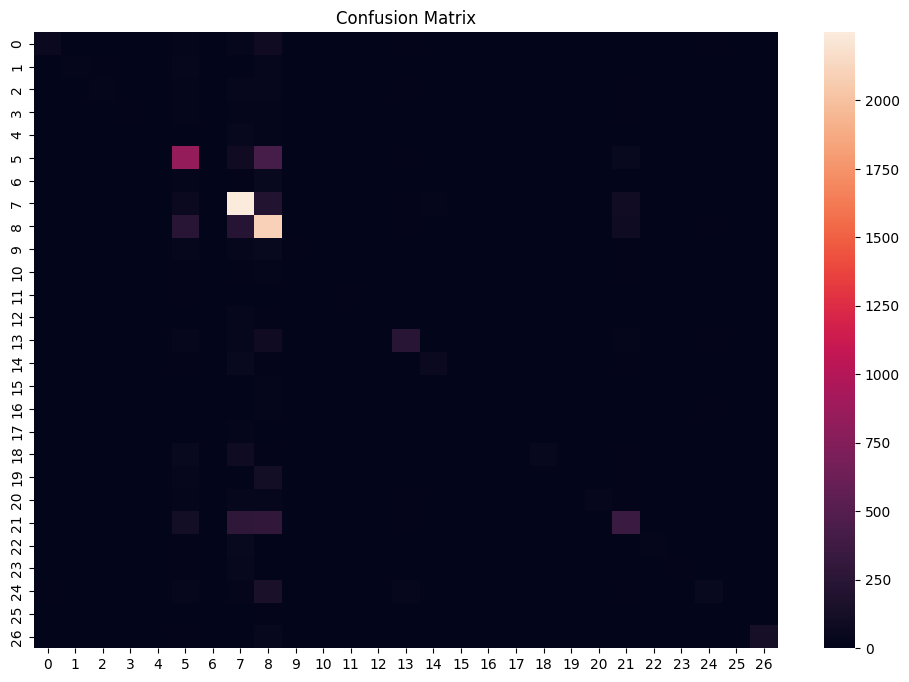

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12,8))
sns.heatmap(cm)
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# sample = [
#     "A detective investigates a mysterious murder in a haunted mansion."
# ]

# sample_tfidf = tfidf.transform(sample)

# prediction = model.predict(sample_tfidf)

# print("Predicted Genre:", prediction[0])

Predicted Genre: mystery
